In [ ]:
# RUN THIS CELL FIRST — project root + path profile (default / lab machine)
import importlib
import os
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
if not (_root / "repo_paths.py").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))
os.chdir(_root)

os.environ["FS_PROFILE"] = "default"

import repo_paths as rp
importlib.reload(rp)
print("ROOT:", rp.ROOT)
print("FS_PROFILE:", os.environ.get("FS_PROFILE"))
print("QUBO file:", rp.QUBO_MATRIX)


In [4]:
import pandas as pd

# File paths
fault_data_path = str(rp.DATA_RAW / "fault_data.csv")
label_data_path = str(rp.DATA_RAW / "labeled_fault_data.csv")
output_path = str(rp.DATA_RAW / "merged_fault_data.csv")

# Load both files
df_fault = pd.read_csv(fault_data_path)
df_label = pd.read_csv(label_data_path)

# Ensure same number of rows
assert len(df_fault) == len(df_label), "Row count mismatch between data files!"

# Merge on index
df_merged = pd.concat([df_fault.reset_index(drop=True), df_label.reset_index(drop=True)], axis=1)

# Optional: Drop duplicate columns if both files have overlapping ones (like Time or Va)
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

# Save merged file
df_merged.to_csv(output_path, index=False)
print(f"✅ Merged file saved to:\n{output_path}")


✅ Merged file saved to:
C:\Users\ishan\OneDrive\Desktop\Feature Selection\merged_fault_data.csv


In [5]:
import pandas as pd

# Load the dataset
file_path = str(rp.DATA_RAW / "merged_fault_data.csv")
df = pd.read_csv(file_path)

# Shape of the dataset
print(f"Dataset shape: {df.shape}")

# Show column names
print("\nColumns:", df.columns.tolist())

# Label distribution
if 'Fault_Label' in df.columns:
    print("\nLabel distribution:")
    print(df['Fault_Label'].value_counts())
else:
    print("\n'Fault_Label' column not found in dataset.")


Dataset shape: (1048575, 10)

Columns: ['Time', 'Va', 'Vb', 'Vc', 'Ia', 'Ib', 'Ic', 'Iref', 'THD', 'Fault_Label']

Label distribution:
Fault_Label
1    748575
0    300000
Name: count, dtype: int64


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv(str(rp.DATA_PROCESSED / "labeled_fault_data_enhanced.csv"))

# Show all column names
print("🧠 All Feature Columns:\n")
for i, col in enumerate(df.columns):
    print(f"{i+1:>2}. {col}")


🧠 All Feature Columns:

 1. Time
 2. Va
 3. Vb
 4. Vc
 5. Ia
 6. Ib
 7. Ic
 8. Iref
 9. THD
10. Fault_Label
11. Vmean
12. Vstd
13. Vdiff_ab
14. Vdiff_bc
15. Vdiff_ca
16. Imean
17. Istd
18. Idiff_ab
19. Idiff_bc
20. Idiff_ca
21. Apparent_Power
22. Power_VaIa
23. Power_VbIb
24. Power_VcIc
25. Iref_error
26. Power_factor
27. Ia_Ib_ratio
28. Ib_Ic_ratio
29. Ic_Ia_ratio
30. dVa_dt
31. dVb_dt
32. dVc_dt
33. dIa_dt
34. dIb_dt
35. dIc_dt
36. dIref_dt
37. dTHD_dt
38. dImean_dt
39. Va_rollmean
40. Va_rollstd
41. Vb_rollmean
42. Vb_rollstd
43. Vc_rollmean
44. Vc_rollstd
45. Ia_rollmean
46. Ia_rollstd
47. Ib_rollmean
48. Ib_rollstd
49. Ic_rollmean
50. Ic_rollstd
51. Iref_rollmean
52. Iref_rollstd
53. THD_rollmean
54. THD_rollstd
55. is_voltage_spike_ab
56. is_voltage_spike_bc
57. is_voltage_spike_ca
58. is_current_imbalanced
59. is_zero_current
60. is_zero_Iref
61. is_THD_below_nominal
62. is_current_surge


C:\Users\ishan\AppData\Local\Temp\ipykernel_29712\117640070.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\ishan\miniconda3\envs\qiskit_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


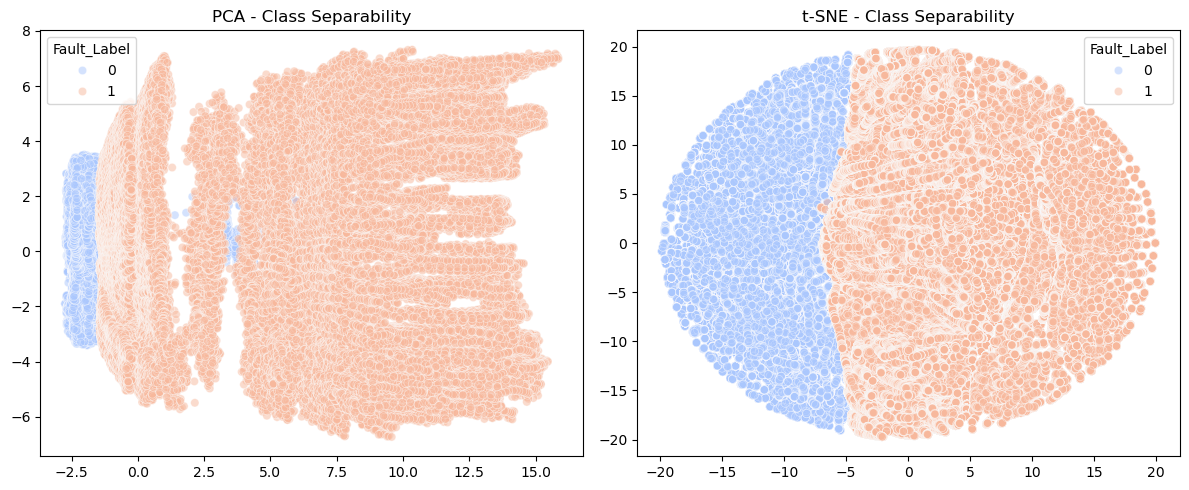

c:\Users\ishan\miniconda3\envs\qiskit_env\lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)



🔁 Highly correlated feature pairs (>0.95): Va                      -29
Vb                      -29
Vc                      -29
Ia                      -29
Ib                      -29
Ic                      -29
Iref                    -29
THD                     -29
Vmean                   -29
Vstd                    -30
Vdiff_ab                -30
Vdiff_bc                -30
Vdiff_ca                -30
Imean                   -30
Istd                    -30
Idiff_ab                -30
Idiff_bc                -30
Idiff_ca                -30
Apparent_Power          -29
Power_VaIa              -30
Power_VbIb              -30
Power_VcIc              -30
Iref_error              -30
Power_factor            -30
Ia_Ib_ratio             -30
Ib_Ic_ratio             -30
Ic_Ia_ratio             -30
dVa_dt                  -30
dVb_dt                  -30
dVc_dt                  -30
dIa_dt                  -30
dIb_dt                  -30
dIc_dt                  -30
dIref_dt                -30
dTHD

In [2]:
import os

# ✅ Fix for joblib CPU warning
os.environ["LOKY_MAX_CPU_COUNT"] = "8"  # Change to your physical core count (e.g., 6 or 12)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# === Load dataset ===
file_path = str(rp.DATA_PROCESSED / "labeled_fault_data_enhanced.csv")
df = pd.read_csv(file_path)

# === Prepare features and label ===
X = df.drop(columns=['Time', 'Fault_Label'])
y = df['Fault_Label']

# === Scale features for PCA/t-SNE ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 1. PCA and t-SNE Visualization ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="coolwarm", alpha=0.5)
plt.title("PCA - Class Separability")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="coolwarm", alpha=0.5)
plt.title("t-SNE - Class Separability")
plt.tight_layout()
plt.show()

# === 2. Correlation Analysis ===
corr_matrix = pd.DataFrame(X_scaled, columns=X.columns).corr()
high_corr_pairs = np.sum((corr_matrix.abs() > 0.95)) - len(X.columns)
print(f"\n🔁 Highly correlated feature pairs (>0.95): {high_corr_pairs // 2}")

# === 3. Low Variance Features ===
low_variance = (X.var() < 1e-5).sum()
print(f"📉 Features with near-zero variance: {low_variance}")

# === 4. Duplicate Sample Check ===
duplicates = df.duplicated().sum()
print(f"🧾 Duplicate rows: {duplicates}")

# === 5. Baseline Models: Learnability Test ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, stratify=y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("\n📊 Logistic Regression Performance:")
print(classification_report(y_test, lr.predict(X_test), digits=4))

# 1-tree Random Forest
rf = RandomForestClassifier(n_estimators=1, max_depth=2, random_state=42)
rf.fit(X_train, y_train)
print("\n🌲 Random Forest (1 tree, depth=2) Performance:")
print(classification_report(y_test, rf.predict(X_test), digits=4))


In [1]:
import pandas as pd
import numpy as np

# === Load original enhanced dataset ===
file_path = str(rp.DATA_PROCESSED / "labeled_fault_data_enhanced.csv")
df = pd.read_csv(file_path)

# === Separate features and label ===
features = df.drop(columns=['Time', 'Fault_Label'])
labels = df['Fault_Label']

# === 1. Add Gaussian Noise (~1% std dev) ===
noise_level = 0.01
features_noise = features + np.random.normal(0, noise_level, size=features.shape)

# === 2. Apply random rolling shifts to simulate sensor delays ===
features_shifted = features.copy()
for col in features_shifted.columns:
    shift_amt = np.random.randint(1, 6)
    features_shifted[col] = features_shifted[col].shift(shift_amt).fillna(method='bfill')

# === 3. Create blended features (0.7 original + 0.3 other random column) ===
features_blend = features.copy()
for col in features.columns:
    mix_col = np.random.choice(features.columns)
    features_blend[col] = 0.7 * features[col] + 0.3 * features[mix_col]

# === 4. Tag and merge all augmented data ===
def tag_augmented(df_part, label_col, tag):
    df_part['Fault_Label'] = label_col
    df_part['Source'] = tag
    return df_part

real = tag_augmented(features.copy(), labels, 'real')
aug_noise = tag_augmented(features_noise.copy(), labels, 'aug_noise')
aug_shifted = tag_augmented(features_shifted.copy(), labels, 'aug_shifted')
aug_blend = tag_augmented(features_blend.copy(), labels, 'aug_blend')

# === 5. Combine all into one DataFrame ===
df_augmented = pd.concat([real, aug_noise, aug_shifted, aug_blend], axis=0).reset_index(drop=True)

# === 6. Save to disk ===
save_path = str(rp.DATA_PROCESSED / "augmented_fault_data.csv")
df_augmented.to_csv(save_path, index=False)

print(f"✅ Augmented dataset saved to:\n{save_path}")
print(f"🧠 Final shape: {df_augmented.shape} (includes real + 3 augmentations)")


C:\Users\ishan\AppData\Local\Temp\ipykernel_23376\4210107973.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  features_shifted[col] = features_shifted[col].shift(shift_amt).fillna(method='bfill')


✅ Augmented dataset saved to:
C:\Users\ishan\OneDrive\Desktop\Feature Selection\augmented_fault_data.csv
🧠 Final shape: (4194300, 62) (includes real + 3 augmentations)


In [3]:
print(df.columns.tolist())


['Va', 'Vb', 'Vc', 'Ia', 'Ib', 'Ic', 'Iref', 'THD', 'Vmean', 'Vstd', 'Vdiff_ab', 'Vdiff_bc', 'Vdiff_ca', 'Imean', 'Istd', 'Idiff_ab', 'Idiff_bc', 'Idiff_ca', 'Apparent_Power', 'Power_VaIa', 'Power_VbIb', 'Power_VcIc', 'Iref_error', 'Power_factor', 'Ia_Ib_ratio', 'Ib_Ic_ratio', 'Ic_Ia_ratio', 'dVa_dt', 'dVb_dt', 'dVc_dt', 'dIa_dt', 'dIb_dt', 'dIc_dt', 'dIref_dt', 'dTHD_dt', 'dImean_dt', 'Va_rollmean', 'Va_rollstd', 'Vb_rollmean', 'Vb_rollstd', 'Vc_rollmean', 'Vc_rollstd', 'Ia_rollmean', 'Ia_rollstd', 'Ib_rollmean', 'Ib_rollstd', 'Ic_rollmean', 'Ic_rollstd', 'Iref_rollmean', 'Iref_rollstd', 'THD_rollmean', 'THD_rollstd', 'is_voltage_spike_ab', 'is_voltage_spike_bc', 'is_voltage_spike_ca', 'is_current_imbalanced', 'is_zero_current', 'is_zero_Iref', 'is_THD_below_nominal', 'is_current_surge', 'Fault_Label', 'Source']


In [9]:
print(df['Source'].value_counts())

Source
real           1048575
aug_noise      1048575
aug_shifted    1048575
aug_blend      1048575
Name: count, dtype: int64


✅ Saved complex and imbalanced 80,000-sample dataset as complex_imbalanced_80k.csv


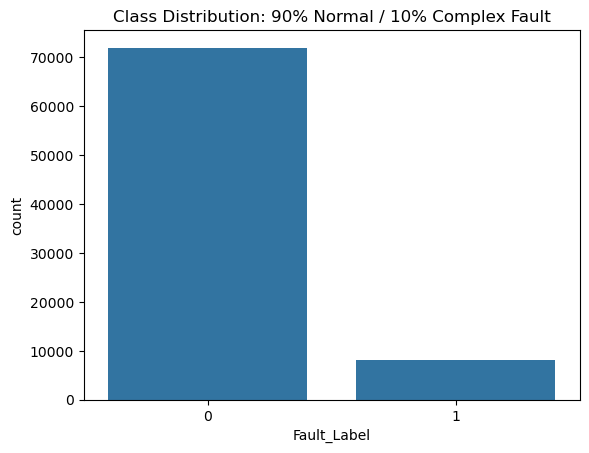

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = str(rp.DATA_PROCESSED / "augmented_fault_data.csv")
df = pd.read_csv(file_path)

# Split data by label
df_normal = df[df['Fault_Label'] == 0]
df_fault = df[df['Fault_Label'] == 1]

# Sample 72,000 normal samples
samples_normal = df_normal.sample(n=72000, random_state=42)

# Sample 8,000 complex fault samples: 2,000 from each source
fault_sources = ['real', 'aug_noise', 'aug_shifted', 'aug_blend']
samples_per_source = 2000

samples_fault = pd.concat([
    df_fault[df_fault['Source'] == src].sample(n=samples_per_source, random_state=42)
    for src in fault_sources
])

# Combine and shuffle
final_complex_imbalanced = pd.concat([samples_normal, samples_fault])
final_complex_imbalanced = final_complex_imbalanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save
final_complex_imbalanced.to_csv(str(rp.COMPLEX_80K), index=False)
print("✅ Saved complex and imbalanced 80,000-sample dataset as complex_imbalanced_80k.csv")

# Visualize class balance
sns.countplot(data=final_complex_imbalanced, x='Fault_Label')
plt.title("Class Distribution: 90% Normal / 10% Complex Fault")
plt.show()


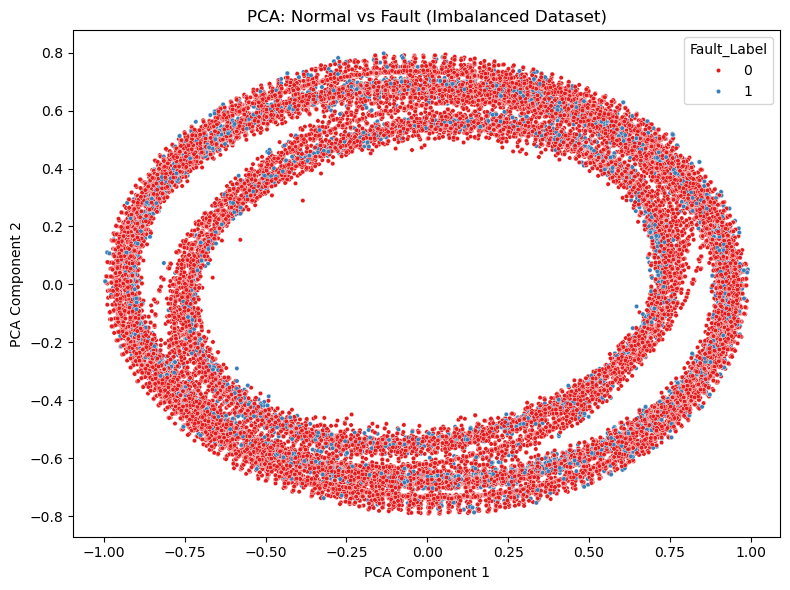

🔍 PCA explained variance: 0.7203


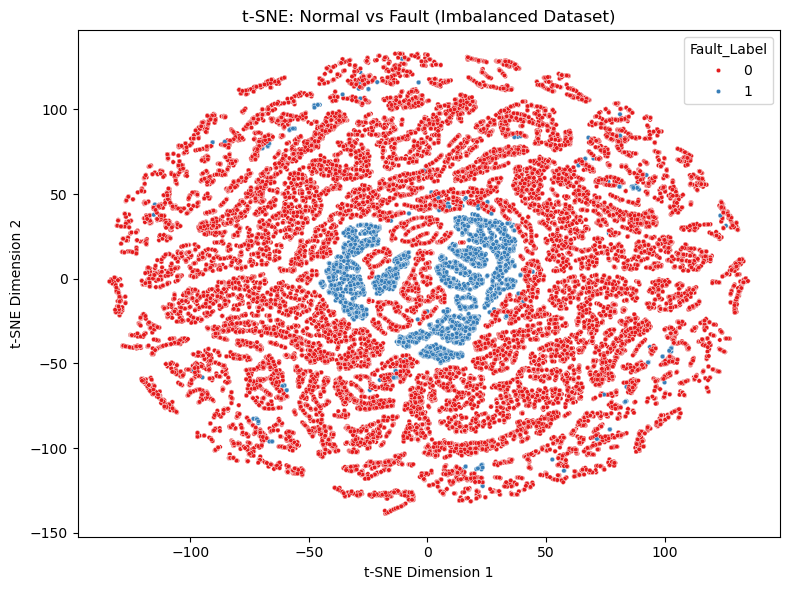

In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(str(rp.COMPLEX_80K))

# Drop non-feature columns
X = df.drop(columns=['Fault_Label', 'Source'])

# Normalize features to [0, 1] for smooth t-SNE performance
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- PCA ----------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['Fault_Label'], palette='Set1', s=10)
plt.title("PCA: Normal vs Fault (Imbalanced Dataset)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Fault_Label")
plt.tight_layout()
plt.show()

print(f"🔍 PCA explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# ---------------- t-SNE ----------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=df['Fault_Label'], palette='Set1', s=10)
plt.title("t-SNE: Normal vs Fault (Imbalanced Dataset)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Fault_Label")
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# Load the CSV file
file_path = str(rp.COMPLEX_80K)
df = pd.read_csv(file_path)

# Count the number of features (columns)
num_features = len(df.columns)

print(f"Number of features in {file_path}: {num_features}")


Number of features in complex_imbalanced_80k.csv: 62


In [4]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import time

def preprocess_data(X):
    """
    Simple preprocessing for mutual information calculation.
    """
    print("Preprocessing data...")
    X_clean = X.copy()
    
    # Handle missing values
    if X_clean.isnull().sum().sum() > 0:
        print(f"Found {X_clean.isnull().sum().sum()} missing values. Imputing with median...")
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Handle infinite values
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
    if X_clean.isnull().sum().sum() > 0:
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Convert categorical/boolean columns to numeric
    for col in X_clean.columns:
        if X_clean[col].dtype == 'object' or X_clean[col].dtype == 'bool':
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
    
    print("Preprocessing completed.")
    return X_clean

def main():
    print("="*60)
    print("MUTUAL INFORMATION ANALYSIS")
    print("="*60)
    
    # Load dataset
    print("Loading dataset...")
    df = pd.read_csv(str(rp.COMPLEX_80K))
    print(f"Dataset shape: {df.shape}")
    
    # Check for required columns
    if 'Fault_Label' not in df.columns:
        print("Error: 'Fault_Label' column not found!")
        return
    
    # Separate features and target
    # Drop Fault_Label and Source (if exists)
    feature_cols = [col for col in df.columns if col not in ['Fault_Label', 'Source']]
    X = df[feature_cols]
    y = df['Fault_Label']
    
    print(f"Number of features: {len(feature_cols)}")
    print(f"Target distribution:")
    print(y.value_counts().sort_index())
    
    # Preprocess features
    X_processed = preprocess_data(X)
    
    # Calculate mutual information for label 1 (fault detection)
    print("\nCalculating mutual information scores...")
    start_time = time.time()
    
    # Focus on label 1 vs label 0 (binary classification)
    y_binary = (y == 1).astype(int)  # 1 for fault, 0 for normal
    
    mi_scores = mutual_info_classif(
        X_processed, y_binary,
        discrete_features=False,
        random_state=42
    )
    
    calculation_time = time.time() - start_time
    print(f"MI calculation completed in {calculation_time:.2f} seconds")
    
    # Create results dataframe
    mi_results = pd.DataFrame({
        'Feature': X_processed.columns,
        'MI_Score': mi_scores
    })
    
    # Sort by MI score (highest first)
    mi_results = mi_results.sort_values('MI_Score', ascending=False).reset_index(drop=True)
    
    # Save results
    mi_results.to_csv(str(rp.MI_SCORES), index=False)
    print(f"\nResults saved to 'mutual_info_scores.csv'")
    
    # Display results
    print(f"\nTop 20 features with highest MI scores for Label 1:")
    print("-" * 60)
    for i, row in mi_results.head(20).iterrows():
        print(f"{i+1:2d}. {row['Feature']:30s} : {row['MI_Score']:.6f}")
    
    # Summary statistics
    print(f"\nSummary Statistics:")
    print(f"Total features analyzed: {len(mi_results)}")
    print(f"Features with MI > 0: {(mi_results['MI_Score'] > 0).sum()}")
    print(f"Average MI score: {mi_results['MI_Score'].mean():.6f}")
    print(f"Maximum MI score: {mi_results['MI_Score'].max():.6f}")
    print(f"Minimum MI score: {mi_results['MI_Score'].min():.6f}")
    
    # Show distribution by thresholds
    print(f"\nFeature distribution by MI thresholds:")
    thresholds = [0.001, 0.01, 0.05, 0.1, 0.2]
    for threshold in thresholds:
        count = (mi_results['MI_Score'] > threshold).sum()
        print(f"MI > {threshold:5.3f}: {count:3d} features")
    
    print(f"\nTotal execution time: {time.time() - start_time + calculation_time:.2f} seconds")
    print("="*60)

if __name__ == "__main__":
    main() 

MUTUAL INFORMATION ANALYSIS
Loading dataset...
Dataset shape: (80000, 62)
Number of features: 60
Target distribution:
Fault_Label
0    72000
1     8000
Name: count, dtype: int64
Preprocessing data...
Preprocessing completed.

Calculating mutual information scores...
MI calculation completed in 12.70 seconds

Results saved to 'mutual_info_scores.csv'

Top 20 features with highest MI scores for Label 1:
------------------------------------------------------------
 1. Apparent_Power                 : 0.321559
 2. dImean_dt                      : 0.319239
 3. Iref_error                     : 0.277650
 4. Imean                          : 0.274360
 5. Ic_rollmean                    : 0.264595
 6. Ib_rollmean                    : 0.260986
 7. Ia_rollmean                    : 0.260043
 8. Iref_rollmean                  : 0.223068
 9. Ic                             : 0.218400
10. Ia                             : 0.217111
11. Ib                             : 0.216556
12. Idiff_ab                

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

def preprocess_data(X):
    """
    Simple preprocessing for permutation importance calculation.
    """
    print("Preprocessing data...")
    X_clean = X.copy()
    
    # Handle missing values
    if X_clean.isnull().sum().sum() > 0:
        print(f"Found {X_clean.isnull().sum().sum()} missing values. Imputing with median...")
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Handle infinite values
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
    if X_clean.isnull().sum().sum() > 0:
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Convert categorical/boolean columns to numeric
    for col in X_clean.columns:
        if X_clean[col].dtype == 'object' or X_clean[col].dtype == 'bool':
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
    
    print("Preprocessing completed.")
    return X_clean

def check_feature_correlation_with_target(X, y):
    """
    Check for potential data leakage by examining feature-target correlations.
    """
    print("\nChecking for potential data leakage...")
    
    correlations = []
    for col in X.columns:
        try:
            corr = np.corrcoef(X[col], y)[0, 1]
            correlations.append({'Feature': col, 'Correlation': abs(corr)})
        except:
            correlations.append({'Feature': col, 'Correlation': 0.0})
    
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('Correlation', ascending=False)
    
    print("Top 10 features with highest correlation to target:")
    for i, row in corr_df.head(10).iterrows():
        print(f"  {row['Feature']:30s} : {row['Correlation']:.6f}")
    
    # Check for suspiciously high correlations
    high_corr = corr_df[corr_df['Correlation'] > 0.9]
    if len(high_corr) > 0:
        print(f"\n⚠️  WARNING: Found {len(high_corr)} features with correlation > 0.9 (potential data leakage)")
        for i, row in high_corr.iterrows():
            print(f"  {row['Feature']:30s} : {row['Correlation']:.6f}")
    
    return corr_df

def main():
    print("="*70)
    print("REALISTIC PERMUTATION IMPORTANCE ANALYSIS")
    print("="*70)
    
    # Load dataset
    print("Loading dataset...")
    df = pd.read_csv(str(rp.COMPLEX_80K))
    print(f"Dataset shape: {df.shape}")
    
    # Check for required columns
    if 'Fault_Label' not in df.columns:
        print("Error: 'Fault_Label' column not found!")
        return
    
    # Separate features and target
    feature_cols = [col for col in df.columns if col not in ['Fault_Label', 'Source']]
    X = df[feature_cols]
    y = df['Fault_Label']
    
    print(f"Number of features: {len(feature_cols)}")
    print(f"Target distribution:")
    print(y.value_counts().sort_index())
    
    # Preprocess features
    X_processed = preprocess_data(X)
    
    # Focus on label 1 vs label 0 (binary classification)
    y_binary = (y == 1).astype(int)
    
    # Check for data leakage
    corr_df = check_feature_correlation_with_target(X_processed, y_binary)
    
    # Split data for training and testing
    print("\nSplitting data...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y_binary, 
        test_size=0.3,  # Larger test set
        stratify=y_binary, 
        random_state=42
    )
    
    print(f"Train set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")
    
    # Train MULTIPLE models with different complexities
    models = {
        'Simple RF': RandomForestClassifier(
            n_estimators=50,
            max_depth=5,  # Shallow trees
            min_samples_split=100,
            min_samples_leaf=50,
            random_state=42,
            class_weight='balanced'
        ),
        'Medium RF': RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            min_samples_split=50,
            min_samples_leaf=20,
            random_state=42,
            class_weight='balanced'
        ),
        'Complex RF': RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            class_weight='balanced'
        )
    }
    
    results = {}
    
    for model_name, rf_model in models.items():
        print(f"\n{'='*50}")
        print(f"ANALYZING: {model_name}")
        print('='*50)
        
        # Train model
        print(f"Training {model_name}...")
        model_start_time = time.time()
        rf_model.fit(X_train, y_train)
        model_time = time.time() - model_start_time
        
        # Evaluate model performance
        train_pred = rf_model.predict(X_train)
        test_pred = rf_model.predict(X_test)
        
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        
        print(f"Model training completed in {model_time:.2f} seconds")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Test Accuracy:  {test_acc:.4f}")
        print(f"Overfitting: {train_acc - test_acc:.4f}")
        
        # Only calculate PI if model is not perfect (to get meaningful results)
        if test_acc < 0.999:  # If not perfect
            print(f"Calculating permutation importance for {model_name}...")
            pi_start_time = time.time()
            
            pi_results = permutation_importance(
                rf_model, X_test, y_test,
                n_repeats=5,  # Fewer repeats for speed
                scoring='accuracy',
                random_state=42,
                n_jobs=-1
            )
            
            pi_time = time.time() - pi_start_time
            print(f"PI calculation completed in {pi_time:.2f} seconds")
            
            # Create results dataframe
            pi_results_df = pd.DataFrame({
                'Feature': X_processed.columns,
                'PI_Mean': pi_results.importances_mean,
                'PI_Std': pi_results.importances_std
            })
            
            # Sort by PI score (highest first)
            pi_results_df = pi_results_df.sort_values('PI_Mean', ascending=False).reset_index(drop=True)
            
            # Save results
            filename = str(rp.DATA_FEATURES / f'pi_scores_{model_name.lower().replace(" ", "_")}.csv')
            pi_results_df.to_csv(filename, index=False)
            print(f"Results saved to '{filename}'")
            
            # Display top results
            print(f"\nTop 15 features with highest PI scores:")
            print("-" * 70)
            for i, row in pi_results_df.head(15).iterrows():
                print(f"{i+1:2d}. {row['Feature']:30s} : {row['PI_Mean']:.6f} ± {row['PI_Std']:.6f}")
            
            # Summary statistics
            print(f"\nSummary for {model_name}:")
            print(f"Features with PI > 0: {(pi_results_df['PI_Mean'] > 0).sum()}")
            print(f"Features with PI > 0.001: {(pi_results_df['PI_Mean'] > 0.001).sum()}")
            print(f"Features with PI > 0.01: {(pi_results_df['PI_Mean'] > 0.01).sum()}")
            print(f"Average PI score: {pi_results_df['PI_Mean'].mean():.6f}")
            print(f"Maximum PI score: {pi_results_df['PI_Mean'].max():.6f}")
            
            results[model_name] = pi_results_df
            
        else:
            print(f"⚠️  {model_name} achieved perfect accuracy - PI scores will be near zero!")
            print("This suggests potential data leakage or overfitting.")
    
    # Summary
    print(f"\n{'='*70}")
    print("ANALYSIS SUMMARY")
    print('='*70)
    
    if len(results) > 0:
        print("Models with meaningful PI scores:")
        for model_name, pi_df in results.items():
            top_feature = pi_df.iloc[0]
            print(f"  {model_name}: Top feature = {top_feature['Feature']} (PI = {top_feature['PI_Mean']:.6f})")
    else:
        print("⚠️  All models achieved perfect or near-perfect accuracy!")
        print("This strongly suggests:")
        print("  1. Data leakage (features calculated after fault occurs)")
        print("  2. Synthetic/artificial data with perfect separation")
        print("  3. Need to remove highly correlated features")
        
        print(f"\nRecommendations:")
        print("  1. Check if derivative features (dX_dt) are calculated correctly")
        print("  2. Remove features with correlation > 0.9 with target")
        print("  3. Use simpler models or add regularization")
        print("  4. Verify data collection methodology")

if __name__ == "__main__":
    main() 

REALISTIC PERMUTATION IMPORTANCE ANALYSIS
Loading dataset...
Dataset shape: (80000, 62)
Number of features: 60
Target distribution:
Fault_Label
0    72000
1     8000
Name: count, dtype: int64
Preprocessing data...
Preprocessing completed.

Checking for potential data leakage...
Top 10 features with highest correlation to target:
  Ic_rollmean                    : 0.575472
  Ic                             : 0.530062
  Ia_rollmean                    : 0.513672
  Ib_rollmean                    : 0.493791
  Ib                             : 0.476799
  Ia                             : 0.472995
  Ia_rollstd                     : 0.408886
  Iref                           : 0.346137
  Ic_rollstd                     : 0.337702
  is_THD_below_nominal           : 0.326598

Splitting data...
Train set: 56,000 samples
Test set: 24,000 samples

ANALYZING: Simple RF
Training Simple RF...
Model training completed in 10.81 seconds
Train Accuracy: 0.9985
Test Accuracy:  0.9986
Overfitting: -0.0002
Calcul

In [7]:
import pandas as pd

def main():
    print("Finding features with non-zero scores in BOTH PI and MI...")
    
    # Load PI scores
    try:
        pi_df = pd.read_csv(str(rp.PI_SCORES_RF))
        print(f"Loaded PI scores: {len(pi_df)} features")
    except FileNotFoundError:
        print("Error: 'pi_scores_simple_rf.csv' not found!")
        return
    
    # Load MI scores
    try:
        mi_df = pd.read_csv(str(rp.MI_SCORES))
        print(f"Loaded MI scores: {len(mi_df)} features")
    except FileNotFoundError:
        print("Error: 'mutual_info_scores.csv' not found!")
        return
    
    # Filter for non-zero scores
    pi_nonzero = pi_df[pi_df['PI_Mean'] > 0]
    mi_nonzero = mi_df[mi_df['MI_Score'] > 0]
    
    print(f"PI features with score > 0: {len(pi_nonzero)}")
    print(f"MI features with score > 0: {len(mi_nonzero)}")
    
    # Find features that have non-zero scores in BOTH
    combined = pd.merge(pi_nonzero[['Feature', 'PI_Mean']], 
                       mi_nonzero[['Feature', 'MI_Score']], 
                       on='Feature', 
                       how='inner')
    
    print(f"Features with non-zero scores in BOTH: {len(combined)}")
    
    if len(combined) == 0:
        print("No features found with non-zero scores in both methods!")
        return
    
    # Sort by PI score (descending)
    combined = combined.sort_values('PI_Mean', ascending=False).reset_index(drop=True)
    
    # Save results
    combined.to_csv(str(rp.NONZERO_BOTH), index=False)
    print(f"Results saved to 'nonzero_features_both.csv'")
    
    # Display results
    print(f"\nFeatures with non-zero scores in BOTH PI and MI:")
    print("-" * 60)
    print(f"{'#':<3} {'Feature':<30} {'PI_Score':<12} {'MI_Score':<12}")
    print("-" * 60)
    
    for i, row in combined.iterrows():
        print(f"{i+1:<3} {row['Feature']:<30} {row['PI_Mean']:<12.6f} {row['MI_Score']:<12.6f}")
    
    print(f"\nTotal: {len(combined)} features")

if __name__ == "__main__":
    main() 

Finding features with non-zero scores in BOTH PI and MI...
Loaded PI scores: 60 features
Loaded MI scores: 60 features
PI features with score > 0: 35
MI features with score > 0: 59
Features with non-zero scores in BOTH: 35
Results saved to 'nonzero_features_both.csv'

Features with non-zero scores in BOTH PI and MI:
------------------------------------------------------------
#   Feature                        PI_Score     MI_Score    
------------------------------------------------------------
1   THD                            0.001875     0.105151    
2   Iref_error                     0.000808     0.277650    
3   Imean                          0.000458     0.274360    
4   Istd                           0.000300     0.196108    
5   Ib                             0.000225     0.216556    
6   Ic                             0.000225     0.218400    
7   Iref_rollmean                  0.000208     0.223068    
8   Ic_Ia_ratio                    0.000150     0.021527    
9   dImean_

In [8]:
import pandas as pd

def main():
    print("Selecting top 25 features for feature selection...")
    
    # Load the combined results
    try:
        df = pd.read_csv(str(rp.NONZERO_BOTH))
        print(f"Loaded {len(df)} features with non-zero scores in both PI and MI")
    except FileNotFoundError:
        print("Error: 'nonzero_features_both.csv' not found!")
        print("Please run nonzero_features.py first.")
        return
    
    # Select top 25 features (already sorted by PI score)
    top_25 = df.head(25).copy()
    
    print(f"\nTop 25 features selected for feature selection:")
    print("-" * 70)
    print(f"{'Rank':<4} {'Feature':<30} {'PI_Score':<12} {'MI_Score':<12}")
    print("-" * 70)
    
    for i, row in top_25.iterrows():
        print(f"{i+1:<4} {row['Feature']:<30} {row['PI_Mean']:<12.6f} {row['MI_Score']:<12.6f}")
    
    # Save top 25 features
    top_25.to_csv(str(rp.TOP25_FEATURES), index=False)
    print(f"\n✓ Top 25 features saved to 'top_25_features.csv'")
    
    # Save just the feature names for easy use
    feature_names = top_25['Feature'].tolist()
    feature_names_df = pd.DataFrame({'Feature': feature_names})
    feature_names_df.to_csv(str(rp.TOP25_NAMES), index=False)
    print(f"✓ Feature names saved to 'top_25_feature_names.csv'")
    
    # Summary statistics
    print(f"\nSummary of selected features:")
    print(f"Total features selected: 25")
    print(f"PI score range: {top_25['PI_Mean'].min():.6f} to {top_25['PI_Mean'].max():.6f}")
    print(f"MI score range: {top_25['MI_Score'].min():.6f} to {top_25['MI_Score'].max():.6f}")
    
    # Top 5 features
    print(f"\nTop 5 most important features:")
    for i, row in top_25.head(5).iterrows():
        print(f"  {i+1}. {row['Feature']}")
    
    print(f"\nFiles created:")
    print(f"  - top_25_features.csv (full data)")
    print(f"  - top_25_feature_names.csv (just names)")
    
    print(f"\n🎯 Ready for quantum feature selection with 25 features!")

if __name__ == "__main__":
    main()

Selecting top 25 features for feature selection...
Loaded 35 features with non-zero scores in both PI and MI

Top 25 features selected for feature selection:
----------------------------------------------------------------------
Rank Feature                        PI_Score     MI_Score    
----------------------------------------------------------------------
1    THD                            0.001875     0.105151    
2    Iref_error                     0.000808     0.277650    
3    Imean                          0.000458     0.274360    
4    Istd                           0.000300     0.196108    
5    Ib                             0.000225     0.216556    
6    Ic                             0.000225     0.218400    
7    Iref_rollmean                  0.000208     0.223068    
8    Ic_Ia_ratio                    0.000150     0.021527    
9    dImean_dt                      0.000117     0.319239    
10   dVc_dt                         0.000117     0.055089    
11   is_zero_Iref 

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

def preprocess_data(X):
    """
    Simple preprocessing for correlation calculation.
    """
    print("Preprocessing data...")
    X_clean = X.copy()
    
    # Handle missing values
    if X_clean.isnull().sum().sum() > 0:
        print(f"Found {X_clean.isnull().sum().sum()} missing values. Imputing...")
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Handle infinite values
    X_clean = X_clean.replace([np.inf, -np.inf], np.nan)
    if X_clean.isnull().sum().sum() > 0:
        imputer = SimpleImputer(strategy='median')
        X_clean = pd.DataFrame(imputer.fit_transform(X_clean), 
                              columns=X_clean.columns, 
                              index=X_clean.index)
    
    # Convert categorical/boolean columns to numeric
    for col in X_clean.columns:
        if X_clean[col].dtype == 'object' or X_clean[col].dtype == 'bool':
            le = LabelEncoder()
            X_clean[col] = le.fit_transform(X_clean[col].astype(str))
    
    print("Preprocessing completed.")
    return X_clean

def main():
    print("="*60)
    print("CORRELATION ANALYSIS FOR TOP 25 FEATURES")
    print("="*60)
    
    # Load the top 25 feature names
    try:
        top25_df = pd.read_csv(str(rp.TOP25_NAMES))
        feature_names = top25_df['Feature'].tolist()
        print(f"Loaded {len(feature_names)} top features")
    except FileNotFoundError:
        print("Error: 'top_25_feature_names.csv' not found!")
        print("Please run select_top25_features.py first.")
        return
    
    # Load the main dataset
    try:
        df = pd.read_csv(str(rp.COMPLEX_80K))
        print(f"Loaded dataset: {df.shape[0]:,} samples, {df.shape[1]} columns")
    except FileNotFoundError:
        print("Error: 'complex_imbalanced_80k.csv' not found!")
        return
    
    # Extract only the top 25 features
    missing_features = [f for f in feature_names if f not in df.columns]
    if missing_features:
        print(f"Warning: {len(missing_features)} features not found in dataset:")
        for f in missing_features:
            print(f"  - {f}")
        feature_names = [f for f in feature_names if f in df.columns]
    
    # Select the 25 features from dataset
    X_top25 = df[feature_names].copy()
    print(f"Extracted {len(feature_names)} features from dataset")
    
    # Preprocess the data
    X_processed = preprocess_data(X_top25)
    
    # Calculate correlation matrix
    print("\nCalculating correlation matrix...")
    correlation_matrix = X_processed.corr()
    
    # Save correlation matrix to CSV
    correlation_matrix.to_csv(str(rp.TOP25_CORR_MAT))
    print("✓ Correlation matrix saved to 'top25_correlation_matrix.csv'")
    
    # Display some statistics about correlations
    print(f"\nCorrelation Matrix Statistics:")
    print(f"Matrix size: {correlation_matrix.shape[0]} x {correlation_matrix.shape[1]}")
    
    # Get upper triangle (excluding diagonal) for analysis
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    
    # Flatten and remove NaN values
    correlations = upper_triangle.stack()
    
    print(f"Total correlation pairs: {len(correlations)}")
    print(f"Average correlation: {correlations.mean():.4f}")
    print(f"Max correlation: {correlations.max():.4f}")
    print(f"Min correlation: {correlations.min():.4f}")
    
    # Find high correlations (>0.8)
    high_corr = correlations[abs(correlations) > 0.8]
    print(f"High correlations (|r| > 0.8): {len(high_corr)}")
    
    if len(high_corr) > 0:
        print(f"\nTop 10 highest correlations:")
        print("-" * 60)
        high_corr_sorted = high_corr.reindex(high_corr.abs().sort_values(ascending=False).index)
        for (feat1, feat2), corr in high_corr_sorted.head(10).items():
            print(f"{feat1:<20} - {feat2:<20} : {corr:7.4f}")
    
    # Find moderate correlations (0.5-0.8)
    moderate_corr = correlations[(abs(correlations) > 0.5) & (abs(correlations) <= 0.8)]
    print(f"\nModerate correlations (0.5 < |r| ≤ 0.8): {len(moderate_corr)}")
    
    # Create a summary of correlation ranges
    print(f"\nCorrelation Distribution:")
    print(f"Very High (|r| > 0.9): {len(correlations[abs(correlations) > 0.9])}")
    print(f"High (0.8 < |r| ≤ 0.9): {len(correlations[(abs(correlations) > 0.8) & (abs(correlations) <= 0.9)])}")
    print(f"Moderate (0.5 < |r| ≤ 0.8): {len(correlations[(abs(correlations) > 0.5) & (abs(correlations) <= 0.8)])}")
    print(f"Low (0.3 < |r| ≤ 0.5): {len(correlations[(abs(correlations) > 0.3) & (abs(correlations) <= 0.5)])}")
    print(f"Very Low (|r| ≤ 0.3): {len(correlations[abs(correlations) <= 0.3])}")
    
    # Save correlation summary
    correlation_summary = pd.DataFrame({
        'Feature_1': [pair[0] for pair in correlations.index],
        'Feature_2': [pair[1] for pair in correlations.index],
        'Correlation': correlations.values,
        'Abs_Correlation': abs(correlations.values)
    })
    
    correlation_summary = correlation_summary.sort_values('Abs_Correlation', ascending=False)
    correlation_summary.to_csv(str(rp.TOP25_CORR_PAIRS), index=False)
    print("✓ Correlation pairs saved to 'top25_correlation_pairs.csv'")
    
    print(f"\nFiles created:")
    print(f"  - top25_correlation_matrix.csv (full 25x25 matrix)")
    print(f"  - top25_correlation_pairs.csv (pairwise correlations)")
    
    print(f"\n🎯 Ready for QUBO matrix construction with correlation data!")

if __name__ == "__main__":
    main() 

CORRELATION ANALYSIS FOR TOP 25 FEATURES
Loaded 25 top features
Loaded dataset: 80,000 samples, 62 columns
Extracted 25 features from dataset
Preprocessing data...
Preprocessing completed.

Calculating correlation matrix...
✓ Correlation matrix saved to 'top25_correlation_matrix.csv'

Correlation Matrix Statistics:
Matrix size: 25 x 25
Total correlation pairs: 300
Average correlation: -0.0006
Max correlation: 0.9948
Min correlation: -0.5234
High correlations (|r| > 0.8): 2

Top 10 highest correlations:
------------------------------------------------------------
is_zero_Iref         - Va_rollstd           :  0.9948
Ib                   - Ib_rollmean          :  0.9351

Moderate correlations (0.5 < |r| ≤ 0.8): 2

Correlation Distribution:
Very High (|r| > 0.9): 2
High (0.8 < |r| ≤ 0.9): 0
Moderate (0.5 < |r| ≤ 0.8): 2
Low (0.3 < |r| ≤ 0.5): 14
Very Low (|r| ≤ 0.3): 282
✓ Correlation pairs saved to 'top25_correlation_pairs.csv'

Files created:
  - top25_correlation_matrix.csv (full 25x25

In [1]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService

_token = os.environ.get("IBM_QUANTUM_TOKEN")
if not _token:
    raise ValueError("Set environment variable IBM_QUANTUM_TOKEN to your IBM Quantum API token.")

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='ibm-q/open/main',
    token=_token
)

# Optional: persist credentials locally (not recommended on shared machines)
# QiskitRuntimeService.save_account(channel='ibm_quantum', instance='ibm-q/open/main', token=_token, overwrite=True)

C:\Users\ishan\AppData\Local\Temp\ipykernel_12176\3836866656.py:3: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, ibm_cloud will be the only valid channel. For information on migrating to the new IBM Quantum Platform on the "ibm_cloud" channel, review the migration guide https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp .
  service = QiskitRuntimeService(


In [3]:
import pandas as pd
import numpy as np
import os

def build_qubo_matrix():
    """
    Build QUBO matrix using the objective function:
    Objective = λ Σ (MI_i * PI_i)/Redundancy_Score_i * x_i - μ Σ R_ij*x_i*x_j + γ (Σ x_i - k)²
    
    Where:
    - MI_i: Mutual Information for feature i
    - PI_i: Permutation Importance for feature i  
    - R_ij: Correlation matrix (redundancy)
    - Redundancy_Score_i: Sum of correlations for feature i
    - λ, μ, γ: Hyperparameters
    - k: Desired number of features
    """
    
    print("Building QUBO Matrix for Quantum Feature Selection")
    print("=" * 55)
    
    # --- Load Mutual Information (MI) ---
    print("Loading Mutual Information scores...")
    try:
        MI_df = pd.read_csv(str(rp.MI_SCORES), index_col=0)
        MI_dict = MI_df['MI_Score'].to_dict()
        print(f"Loaded MI for {len(MI_dict)} features")
    except FileNotFoundError:
        print("Error: mutual_info_scores.csv not found!")
        return None
    
    # --- Load Permutation Importance (PI) ---
    print("Loading Permutation Importance scores...")
    try:
        PI_df = pd.read_csv(str(rp.PI_SCORES_RF), index_col=0)
        PI_dict = PI_df['PI_Mean'].to_dict()
        print(f"Loaded PI for {len(PI_dict)} features")
    except FileNotFoundError:
        print("Error: pi_scores_simple_rf.csv not found!")
        return None
    
    # --- Load Correlation Matrix (R) ---
    print("Loading Correlation matrix...")
    try:
        R_df = pd.read_csv(str(rp.TOP25_CORR_MAT), index_col=0)
        features = list(R_df.columns)
        R = R_df.values
        n = len(features)
        print(f"Loaded correlation matrix: {n}x{n} features")
        print(f"Features: {features[:5]}..." if n > 5 else f"Features: {features}")
    except FileNotFoundError:
        print("Error: top25_correlation_matrix.csv not found!")
        return None
    
    # --- Align features across all datasets ---
    print("\nAligning features across datasets...")
    common_features = set(features) & set(MI_dict.keys()) & set(PI_dict.keys())
    print(f"Common features across all datasets: {len(common_features)}")
    
    if len(common_features) == 0:
        print("Error: No common features found across datasets!")
        return None
    
    # Filter to common features and maintain order
    aligned_features = [f for f in features if f in common_features]
    n = len(aligned_features)
    
    print(f"Using {n} aligned features:")
    for i, feature in enumerate(aligned_features, 1):
        print(f"{i:2d}. {feature}")
    
    # --- Extract aligned data ---
    # Reorder correlation matrix
    feature_indices = [features.index(f) for f in aligned_features]
    R_aligned = R[np.ix_(feature_indices, feature_indices)]
    
    # Extract MI and PI for aligned features
    MI_aligned = np.array([MI_dict[f] for f in aligned_features])
    PI_aligned = np.array([PI_dict[f] for f in aligned_features])
    
    print(f"\nData summary:")
    print(f"MI range: [{MI_aligned.min():.6f}, {MI_aligned.max():.6f}]")
    print(f"PI range: [{PI_aligned.min():.6f}, {PI_aligned.max():.6f}]")
    print(f"Correlation range: [{R_aligned.min():.6f}, {R_aligned.max():.6f}]")
    
    # --- Compute Redundancy Score ---
    print("\nComputing redundancy scores...")
    # Redundancy_Score_i = sum of absolute correlations for feature i (excluding diagonal)
    Redundancy_Score = np.abs(R_aligned).sum(axis=1) - np.abs(np.diag(R_aligned))
    
    # Add small epsilon to avoid division by zero
    epsilon = 1e-8
    Redundancy_Score = np.where(Redundancy_Score < epsilon, epsilon, Redundancy_Score)
    
    print(f"Redundancy Score range: [{Redundancy_Score.min():.6f}, {Redundancy_Score.max():.6f}]")
    
    # --- Hyperparameters ---
    print("\nSetting hyperparameters...")
    lambda_param = 1.0    # Weight for relevance term (MI * PI / Redundancy)
    mu_param = 0.5        # Weight for redundancy penalty
    gamma_param = 0.1     # Weight for cardinality constraint
    k = 6                 # Desired number of features
    
    print(f"λ (relevance weight): {lambda_param}")
    print(f"μ (redundancy penalty): {mu_param}")
    print(f"γ (cardinality weight): {gamma_param}")
    print(f"k (target features): {k}")
    
    # --- Build QUBO Matrix ---
    print(f"\nBuilding {n}x{n} QUBO matrix...")
    Q = np.zeros((n, n))
    
    # Diagonal terms: λ * (MI_i * PI_i) / Redundancy_Score_i + γ * (1 - 2k)
    relevance_scores = (MI_aligned * PI_aligned) / Redundancy_Score
    diagonal_terms = lambda_param * relevance_scores + gamma_param * (1 - 2 * k)
    
    print(f"Relevance scores range: [{relevance_scores.min():.6f}, {relevance_scores.max():.6f}]")
    print(f"Diagonal terms range: [{diagonal_terms.min():.6f}, {diagonal_terms.max():.6f}]")
    
    np.fill_diagonal(Q, diagonal_terms)
    
    # Off-diagonal terms: -μ * R_ij + 2γ
    for i in range(n):
        for j in range(i+1, n):
            off_diag_value = -mu_param * R_aligned[i, j] + 2 * gamma_param
            Q[i, j] = off_diag_value
            Q[j, i] = off_diag_value  # Symmetric
    
    off_diag_range = Q[np.triu_indices_from(Q, k=1)]
    print(f"Off-diagonal terms range: [{off_diag_range.min():.6f}, {off_diag_range.max():.6f}]")
    
    # --- Quality checks ---
    print("\nPerforming quality checks...")
    
    # Check for NaNs or Infs
    if np.isnan(Q).any():
        print("WARNING: QUBO matrix contains NaN values!")
        nan_locations = np.where(np.isnan(Q))
        print(f"NaN locations: {list(zip(nan_locations[0], nan_locations[1]))}")
        return None
    
    if np.isinf(Q).any():
        print("WARNING: QUBO matrix contains infinite values!")
        return None
    
    # Check symmetry
    if not np.allclose(Q, Q.T, rtol=1e-10):
        print("WARNING: QUBO matrix is not symmetric!")
        return None
    
    print("✓ Matrix is symmetric")
    print("✓ No NaN or infinite values")
    print(f"✓ Matrix condition number: {np.linalg.cond(Q):.2e}")
    
    # --- Save QUBO matrix ---
    print("\nSaving QUBO matrix...")
    
    # Save as DataFrame with feature names
    qubo_df = pd.DataFrame(Q, index=aligned_features, columns=aligned_features)
    qubo_df.to_csv(str(rp.QUBO_MATRIX))
    print("✓ Saved as qubo_matrix_symmetric.csv")
    
    # Save metadata
    metadata = {
        'n_features': n,
        'features': aligned_features,
        'hyperparameters': {
            'lambda': lambda_param,
            'mu': mu_param, 
            'gamma': gamma_param,
            'k': k
        },
        'data_ranges': {
            'MI': [float(MI_aligned.min()), float(MI_aligned.max())],
            'PI': [float(PI_aligned.min()), float(PI_aligned.max())],
            'correlation': [float(R_aligned.min()), float(R_aligned.max())],
            'redundancy_score': [float(Redundancy_Score.min()), float(Redundancy_Score.max())],
            'qubo_diagonal': [float(diagonal_terms.min()), float(diagonal_terms.max())],
            'qubo_off_diagonal': [float(off_diag_range.min()), float(off_diag_range.max())]
        }
    }
    
    import json
    with open(rp.QUBO_META, 'w') as f:
        json.dump(metadata, f, indent=2)
    print("✓ Saved metadata as qubo_metadata.json")
    
    # --- Display feature rankings ---
    print(f"\nTop features by relevance score (MI * PI / Redundancy):")
    feature_relevance = list(zip(aligned_features, relevance_scores))
    feature_relevance.sort(key=lambda x: x[1], reverse=True)
    
    for i, (feature, score) in enumerate(feature_relevance[:10], 1):
        mi_val = MI_dict[feature]
        pi_val = PI_dict[feature]
        red_score = Redundancy_Score[aligned_features.index(feature)]
        print(f"{i:2d}. {feature:20s} | Rel={score:.6f} | MI={mi_val:.4f} | PI={pi_val:.6f} | Red={red_score:.4f}")
    
    print(f"\n" + "=" * 55)
    print("QUBO MATRIX SUCCESSFULLY BUILT")
    print("=" * 55)
    print(f"Matrix size: {n}x{n}")
    print(f"Matrix range: [{Q.min():.6f}, {Q.max():.6f}]")
    print(f"Ready for quantum optimization!")
    
    return Q, aligned_features, metadata

def main():
    """Main function to build QUBO matrix"""
    try:
        result = build_qubo_matrix()
        if result is not None:
            Q, features, metadata = result
            print(f"\nQUBO matrix built successfully with {len(features)} features")
            print("Files created:")
            print("  - qubo_matrix_symmetric.csv")
            print("  - qubo_metadata.json")
        else:
            print("Failed to build QUBO matrix")
    except Exception as e:
        print(f"Error building QUBO matrix: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main() 

Building QUBO Matrix for Quantum Feature Selection
Loading Mutual Information scores...
Loaded MI for 60 features
Loading Permutation Importance scores...
Loaded PI for 60 features
Loading Correlation matrix...
Loaded correlation matrix: 25x25 features
Features: ['THD', 'Iref_error', 'Imean', 'Istd', 'Ib']...

Aligning features across datasets...
Common features across all datasets: 25
Using 25 aligned features:
 1. THD
 2. Iref_error
 3. Imean
 4. Istd
 5. Ib
 6. Ic
 7. Iref_rollmean
 8. Ic_Ia_ratio
 9. dImean_dt
10. dVc_dt
11. is_zero_Iref
12. dVb_dt
13. Ib_rollmean
14. Power_factor
15. dVa_dt
16. Apparent_Power
17. Power_VbIb
18. Vmean
19. Ic_rollstd
20. Vb_rollstd
21. Idiff_ca
22. dIa_dt
23. Va_rollstd
24. Ia_rollstd
25. Power_VcIc

Data summary:
MI range: [0.000198, 0.321559]
PI range: [0.000025, 0.001875]
Correlation range: [-0.523375, 1.000000]

Computing redundancy scores...
Redundancy Score range: [0.053665, 2.687570]

Setting hyperparameters...
λ (relevance weight): 1.0
μ (re

In [24]:
import numpy as np
import pandas as pd
import pickle
import os
import time
from datetime import datetime
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, Session
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import SetLayout
from qiskit import transpile

class QuantumFeatureSelector:
    def __init__(self, qubo_matrix_file=str(rp.QUBO_MATRIX), checkpoint_file=str(rp.CHECKPOINT_PKL)):
        self.qubo_matrix_file = qubo_matrix_file
        self.checkpoint_file = checkpoint_file
        self.service = None
        self.backend = None
        self.features = None
        self.qubo_matrix = None
        self.n_features = 0
        self.best_params = None
        self.best_value = None
        self.iteration = 0
        
    def setup_quantum_service(self):
        """Initialize quantum service and find least busy backend"""
        print("Setting up quantum service...")
        
        # Initialize service
        _token = os.environ.get("IBM_QUANTUM_TOKEN")
        if not _token:
            raise ValueError("Set environment variable IBM_QUANTUM_TOKEN to your IBM Quantum API token.")
        self.service = QiskitRuntimeService(
            channel='ibm_quantum',
            instance='ibm-q/open/main',
            token=_token
        )
        
        # Focus on your specific free backends
        preferred_backends = ['ibm_sherbrooke', 'ibm_brisbane']
        
        backends = self.service.backends(simulator=False, operational=True)
        available_backends = [b for b in backends if b.name in preferred_backends]
        
        print(f"Found {len(available_backends)} preferred backends available")
        
        # Find least busy backend
        least_busy_backend = None
        min_queue = float('inf')
        
        for backend in available_backends:
            try:
                status = backend.status()
                queue_length = status.pending_jobs
                print(f"{backend.name}: {queue_length} pending jobs, operational: {status.operational}")
                
                if status.operational and queue_length < min_queue:
                    min_queue = queue_length
                    least_busy_backend = backend
            except Exception as e:
                print(f"Error checking {backend.name}: {e}")
        
        if least_busy_backend is None:
            raise RuntimeError("No operational preferred backends found!")
        
        self.backend = least_busy_backend
        print(f"✓ Selected: {self.backend.name} with {min_queue} pending jobs")
        print(f"✓ Specs: 127 qubits, Eagle r3 processor")
        
    def load_qubo_matrix(self):
        """Load QUBO matrix from CSV file"""
        print(f"Loading QUBO matrix from {self.qubo_matrix_file}...")
        
        qubo_df = pd.read_csv(self.qubo_matrix_file, index_col=0)
        self.features = list(qubo_df.columns)
        self.qubo_matrix = qubo_df.values
        self.n_features = len(self.features)
        
        print(f"✓ Loaded {self.n_features} features")
        print(f"✓ QUBO range: [{self.qubo_matrix.min():.4f}, {self.qubo_matrix.max():.4f}]")
        print(f"✓ Matrix is properly formatted for minimization (negative diagonal values)")
    
    def create_qaoa_circuit(self, gamma, beta):
        """Create QAOA circuit"""
        qc = QuantumCircuit(self.n_features)
        qc.h(range(self.n_features))
        
        # Cost layer
        for i in range(self.n_features):
            if abs(self.qubo_matrix[i, i]) > 1e-10:
                qc.rz(2 * gamma * self.qubo_matrix[i, i], i)
            for j in range(i + 1, self.n_features):
                if abs(self.qubo_matrix[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * gamma * self.qubo_matrix[i, j], j)
                    qc.cx(i, j)
        
        # Mixer layer
        for i in range(self.n_features):
            qc.rx(2 * beta, i)
        
        return qc
    
    def create_cost_hamiltonian(self):
        """Create cost Hamiltonian"""
        pauli_list = []
        
        for i in range(self.n_features):
            if abs(self.qubo_matrix[i, i]) > 1e-10:
                pauli_str = ['I'] * self.n_features
                pauli_str[i] = 'Z'
                pauli_list.append((''.join(pauli_str), self.qubo_matrix[i, i]))
        
        for i in range(self.n_features):
            for j in range(i + 1, self.n_features):
                if abs(self.qubo_matrix[i, j]) > 1e-10:
                    pauli_str = ['I'] * self.n_features
                    pauli_str[i] = 'Z'
                    pauli_str[j] = 'Z'
                    pauli_list.append((''.join(pauli_str), self.qubo_matrix[i, j]))
        
        pauli_list.append(('I' * self.n_features, 0.0))
        return SparsePauliOp.from_list(pauli_list)
    
    def objective_function(self, params, estimator, hamiltonian):
        """Objective function for optimization"""
        try:
            gamma, beta = params
            qc = self.create_qaoa_circuit(gamma, beta)
            
            # Fix: Only use the first 25 qubits in the coupling map
            full_coupling_map = self.backend.configuration().coupling_map
            coupling_map = [edge for edge in full_coupling_map if edge[0] < self.n_features and edge[1] < self.n_features]
            basis_gates = self.backend.configuration().basis_gates
            physical_qubits = list(range(self.n_features))
            transpiled_qc = transpile(
                qc,
                optimization_level=1,
                initial_layout=physical_qubits,
                coupling_map=coupling_map,
                basis_gates=basis_gates
            )
            print(f"Transpiled circuit width: {transpiled_qc.num_qubits}")
            print(f"Hamiltonian width: {hamiltonian.num_qubits}")
            
            # Run estimation
            job = estimator.run([(transpiled_qc, hamiltonian)])
            result = job.result()
            
            # Get expectation value
            if hasattr(result[0].data, 'evs'):
                ev = result[0].data.evs
            else:
                ev = result[0].data.expectation_values
            expectation_value = np.asarray(ev).item()
            
            self.iteration += 1
            self.save_checkpoint(params, expectation_value)
            
            print(f"Iter {self.iteration}: γ={gamma:.4f}, β={beta:.4f}, Cost={expectation_value:.6f}")
            return expectation_value
            
        except Exception as e:
            print(f"\nError during quantum evaluation: {e}")
            return 1e6
    
    def save_checkpoint(self, params, value):
        """Save checkpoint"""
        checkpoint_data = {
            'iteration': self.iteration,
            'best_params': params,
            'best_value': value,
            'timestamp': datetime.now().isoformat(),
            'backend_name': self.backend.name,
            'n_features': self.n_features
        }
        
        with open(self.checkpoint_file, 'wb') as f:
            pickle.dump(checkpoint_data, f)
    
    def load_checkpoint(self):
        """Load checkpoint"""
        try:
            with open(self.checkpoint_file, 'rb') as f:
                checkpoint_data = pickle.load(f)
            
            self.iteration = checkpoint_data.get('iteration', 0)
            self.best_params = checkpoint_data.get('best_params', None)
            self.best_value = checkpoint_data.get('best_value', None)
            
            if self.best_params:
                print(f"✓ Resuming from iteration {self.iteration}")
            return True
            
        except FileNotFoundError:
            print("✓ Starting fresh optimization")
            return False
    
    def get_selected_features(self, n_top=6):
        """Get top features based on QUBO diagonal values"""
        diagonal_values = np.diag(self.qubo_matrix)
        top_indices = np.argsort(diagonal_values)[:n_top]
        return [self.features[i] for i in top_indices]
    
    def run_optimization(self, max_iterations=8):
        """Run the quantum optimization"""
        print("\n🚀 Starting Quantum Feature Selection...")
        
        self.setup_quantum_service()
        self.load_qubo_matrix()
        
        hamiltonian = self.create_cost_hamiltonian()
        print(f"✓ Created Hamiltonian with {len(hamiltonian)} terms")
        
        self.load_checkpoint()
        
        # Initialize parameters
        if self.best_params is None:
            initial_params = [np.random.uniform(0, np.pi) for _ in range(2)]
        else:
            initial_params = self.best_params
            
        print(f"✓ Starting with γ={initial_params[0]:.4f}, β={initial_params[1]:.4f}")
        
        stats = {'successful_evals': 0, 'best_real_cost': None, 'best_real_params': None}
        
        try:
            # Create session and estimator
            with Session(self.backend) as session:
                estimator = Estimator(session)
                print(f"✓ Session active on {self.backend.name}")
                
                def wrapped_objective(params, estimator, hamiltonian):
                    cost = self.objective_function(params, estimator, hamiltonian)
                    if cost != 1e6:
                        stats['successful_evals'] += 1
                        if stats['best_real_cost'] is None or cost < stats['best_real_cost']:
                            stats['best_real_cost'] = cost
                            stats['best_real_params'] = params
                    return cost
                
                # Run optimization
                result = minimize(
                    wrapped_objective,
                    initial_params,
                    args=(estimator, hamiltonian),
                    method='COBYLA',
                    options={'maxiter': max_iterations, 'disp': True}
                )
                
                print(f"\n🎯 Optimization Results:")
                print(f"✓ Best γ={result.x[0]:.6f}, β={result.x[1]:.6f}")
                print(f"✓ Best cost: {result.fun:.6f}")
                print(f"✓ Converged: {result.success}")
                print(f"✓ Successful quantum evaluations: {stats['successful_evals']}")
                
                if stats['successful_evals'] > 0:
                    selected_features = self.get_selected_features(6)
                    print(f"\n🏆 Top 6 Selected Features:")
                    for i, feature in enumerate(selected_features, 1):
                        diag_val = self.qubo_matrix[self.features.index(feature), self.features.index(feature)]
                        print(f"{i}. {feature:20s} | Score: {diag_val:.6f}")
                else:
                    print("\n⚠️ No quantum hardware evaluations were successful. No features selected.")
                    selected_features = []
                
                # Save results
                final_results = {
                    'optimization_result': result,
                    'selected_features': selected_features,
                    'backend_used': self.backend.name,
                    'total_iterations': self.iteration,
                    'timestamp': datetime.now().isoformat(),
                    'successful_evals': stats['successful_evals']
                }
                
                with open(rp.QUANTUM_RESULTS_PKL, 'wb') as f:
                    pickle.dump(final_results, f)
                
                print(f"\n✅ Complete! Used {self.iteration} quantum evaluations on {self.backend.name}")
                return result, selected_features
                
        except Exception as e:
            print(f"\n⚠️ Optimization interrupted: {e}")
            if stats['successful_evals'] > 0:
                selected_features = self.get_selected_features(6)
                print(f"\nCurrent best features:")
                for i, feature in enumerate(selected_features, 1):
                    print(f"{i}. {feature}")
            else:
                print("\n⚠️ No quantum hardware evaluations were successful. No features selected.")
            raise

def main():
    print("🔮 Quantum Feature Selection - IBM Free Backends")
    print("=" * 50)
    
    selector = QuantumFeatureSelector()
    
    try:
        result, features = selector.run_optimization(max_iterations=6)
        print(f"\n🎉 Success! Selected {len(features)} features using {selector.backend.name}")
        
    except KeyboardInterrupt:
        print("\n⏹️ Stopped by user")
    except Exception as e:
        print(f"\n❌ Error: {e}")

if __name__ == "__main__":
    main() 

🔮 Quantum Feature Selection - IBM Free Backends

🚀 Starting Quantum Feature Selection...
Setting up quantum service...
Found 2 preferred backends available
ibm_brisbane: 34 pending jobs, operational: True
ibm_sherbrooke: 4 pending jobs, operational: True
✓ Selected: ibm_sherbrooke with 4 pending jobs
✓ Specs: 127 qubits, Eagle r3 processor
Loading QUBO matrix from qubo_matrix_symmetric.csv...
✓ Loaded 25 features
✓ QUBO range: [-1.1000, 0.4617]
✓ Matrix is properly formatted for minimization (negative diagonal values)
✓ Created Hamiltonian with 326 terms
✓ Starting fresh optimization
✓ Starting with γ=3.0313, β=2.6898
✓ Session active on ibm_sherbrooke
Transpiled circuit width: 25
Hamiltonian width: 25
Iter 1: γ=3.0313, β=2.6898, Cost=-1.266300
Transpiled circuit width: 25
Hamiltonian width: 25
Iter 2: γ=4.0313, β=2.6898, Cost=-1.457624
Transpiled circuit width: 25
Hamiltonian width: 25
Iter 3: γ=4.0313, β=3.6898, Cost=-1.563740
Transpiled circuit width: 25
Hamiltonian width: 25
Iter 4

In [26]:
import pandas as pd

df = pd.read_csv(str(rp.COMPLEX_80K))
print("Columns in CSV:")
for col in df.columns:
    print(f"- {col}")

Columns in CSV:
- Va
- Vb
- Vc
- Ia
- Ib
- Ic
- Iref
- THD
- Vmean
- Vstd
- Vdiff_ab
- Vdiff_bc
- Vdiff_ca
- Imean
- Istd
- Idiff_ab
- Idiff_bc
- Idiff_ca
- Apparent_Power
- Power_VaIa
- Power_VbIb
- Power_VcIc
- Iref_error
- Power_factor
- Ia_Ib_ratio
- Ib_Ic_ratio
- Ic_Ia_ratio
- dVa_dt
- dVb_dt
- dVc_dt
- dIa_dt
- dIb_dt
- dIc_dt
- dIref_dt
- dTHD_dt
- dImean_dt
- Va_rollmean
- Va_rollstd
- Vb_rollmean
- Vb_rollstd
- Vc_rollmean
- Vc_rollstd
- Ia_rollmean
- Ia_rollstd
- Ib_rollmean
- Ib_rollstd
- Ic_rollmean
- Ic_rollstd
- Iref_rollmean
- Iref_rollstd
- THD_rollmean
- THD_rollstd
- is_voltage_spike_ab
- is_voltage_spike_bc
- is_voltage_spike_ca
- is_current_imbalanced
- is_zero_current
- is_zero_Iref
- is_THD_below_nominal
- is_current_surge
- Fault_Label
- Source


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quantum-selected features
FEATURES = [
    'Power_factor', 'Va_rollstd', 'dIa_dt', 'is_zero_Iref', 'Ia_rollstd', 'dVa_dt'
]
TARGET = 'Fault_Label'
CSV_FILE = str(rp.COMPLEX_80K)

# Load data
print(f"Loading {CSV_FILE}...")
df = pd.read_csv(CSV_FILE)

# Drop 'Source' column if present
df = df.drop(columns=['Source'], errors='ignore')

# Check for missing features
diff = set(FEATURES + [TARGET]) - set(df.columns)
if diff:
    raise ValueError(f"Missing columns in CSV: {diff}")

# Select features and target
X = df[FEATURES]
y = df[TARGET]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
mlp.fit(X_train, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred)) 

Loading complex_imbalanced_80k.csv...

Test Accuracy: 0.8942

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     14400
           1       0.37      0.08      0.13      1600

    accuracy                           0.89     16000
   macro avg       0.64      0.53      0.54     16000
weighted avg       0.85      0.89      0.86     16000


Confusion Matrix:
[[14181   219]
 [ 1474   126]]


In [29]:
import pandas as pd
import numpy as np
import os
import pickle
import time
from datetime import datetime
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, Session
from qiskit.quantum_info import SparsePauliOp
from scipy.optimize import minimize
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import json
warnings.filterwarnings('ignore')

class QuantumFeatureSelector:
    def __init__(self, 
                 qubo_matrix_file=str(rp.QUBO_MATRIX),
                 checkpoint_file=str(rp.CHECKPOINT_PKL),
                 results_file=str(rp.GRID_RESULTS),
                 state_file=str(rp.GRID_STATE)):
        self.qubo_matrix_file = qubo_matrix_file
        self.checkpoint_file = checkpoint_file
        self.results_file = results_file
        self.state_file = state_file
        self.service = None
        self.backend = None
        self.features = None
        self.qubo_matrix = None
        self.n_features = 0
        self.best_params = None
        self.best_value = None
        self.iteration = 0
        self.X = None  # Will store the full dataset
        self.y = None  # Will store the target variable
        self.current_state = None
        
    def clear_state(self):
        """Clear all state files to start fresh"""
        try:
            # Remove state files
            if os.path.exists(self.state_file):
                os.remove(self.state_file)
                print(f"✓ Cleared state file: {self.state_file}")
            
            if os.path.exists(self.results_file):
                os.remove(self.results_file)
                print(f"✓ Cleared results file: {self.results_file}")
                
            if os.path.exists(self.checkpoint_file):
                os.remove(self.checkpoint_file)
                print(f"✓ Cleared checkpoint file: {self.checkpoint_file}")
                
            print("✓ All state files cleared - starting fresh!")
            return True
        except Exception as e:
            print(f"Error clearing state files: {e}")
            return False
            
    def load_state(self):
        """Load the current state of grid search"""
        try:
            if os.path.exists(self.state_file):
                with open(self.state_file, 'r') as f:
                    self.current_state = json.load(f)
                print(f"✓ Loaded state from {self.state_file}")
                return True
            return False
        except Exception as e:
            print(f"Error loading state: {e}")
            return False
            
    def save_state(self, current_params, results):
        """Save the current state of grid search"""
        try:
            state = {
                'current_params': current_params,
                'completed_combinations': results,
                'timestamp': datetime.now().isoformat(),
                'total_iterations': self.iteration
            }
            with open(self.state_file, 'w') as f:
                json.dump(state, f, indent=2)
            print(f"✓ Saved state to {self.state_file}")
        except Exception as e:
            print(f"Error saving state: {e}")
            
    def update_api_key(self, new_token):
        """Update the IBM Quantum API token"""
        try:
            self.service = QiskitRuntimeService(
                channel='ibm_quantum',
                instance='ibm-q/open/main',
                token=new_token
            )
            print("✓ API token updated successfully")
            return True
        except Exception as e:
            print(f"Error updating API token: {e}")
            return False
            
    def setup_quantum_service(self):
        """Initialize quantum service and find the least busy preferred backend."""
        print("Setting up quantum service...")
        
        # Initialize service
        _token = os.environ.get("IBM_QUANTUM_TOKEN")
        if not _token:
            raise ValueError("Set environment variable IBM_QUANTUM_TOKEN to your IBM Quantum API token.")
        self.service = QiskitRuntimeService(
            channel='ibm_quantum',
            instance='ibm-q/open/main',
            token=_token
        )
        
        # Focus on specific free backends as requested
        preferred_backends = ['ibm_sherbrooke', 'ibm_brisbane']
        print(f"Focusing on preferred backends: {preferred_backends}")

        backends = self.service.backends(simulator=False, operational=True)
        available_backends = [b for b in backends if b.name in preferred_backends]
        
        if not available_backends:
            raise RuntimeError("None of the preferred backends are currently operational.")

        least_busy_backend = None
        min_queue = float('inf')
        
        print("-" * 40)
        for backend in available_backends:
            try:
                status = backend.status()
                queue_length = status.pending_jobs
                print(f"Backend: {backend.name:<15} | Qubits: {backend.num_qubits:<5} | Pending Jobs: {queue_length}")
                
                if status.operational and queue_length < min_queue:
                    min_queue = queue_length
                    least_busy_backend = backend
            except Exception as e:
                print(f"Could not get status for {backend.name}: {e}")
        print("-" * 40)
        
        if least_busy_backend is None:
            raise RuntimeError("Could not find any suitable operational preferred backends!")
        
        self.backend = least_busy_backend
        print(f"✓ Selected best backend: {self.backend.name} with {min_queue} pending jobs")
        
    def load_data(self, data_file="your_data.csv", target_column="target"):
        """Load the dataset"""
        print(f"Loading dataset from {data_file}...")
        df = pd.read_csv(data_file)
        self.X = df.drop(columns=[target_column])
        self.y = df[target_column]
        print(f"✓ Loaded dataset with {self.X.shape[0]} samples and {self.X.shape[1]} features")
        
    def build_qubo_matrix(self, k, lambda_param=1.0, mu_param=0.5, gamma_param=0.1):
        """Build QUBO matrix for feature selection"""
        print(f"\nBuilding QUBO matrix for k={k} features...")
        
        # Load Mutual Information
        MI_df = pd.read_csv(str(rp.MI_SCORES), index_col=0)
        MI_dict = MI_df['MI_Score'].to_dict()
        
        # Load Permutation Importance
        PI_df = pd.read_csv(str(rp.PI_SCORES_RF), index_col=0)
        PI_dict = PI_df['PI_Mean'].to_dict()
        
        # Load Correlation Matrix
        R_df = pd.read_csv(str(rp.TOP25_CORR_MAT), index_col=0)
        features = list(R_df.columns)
        R = R_df.values
        
        # Align features
        common_features = set(features) & set(MI_dict.keys()) & set(PI_dict.keys())
        aligned_features = [f for f in features if f in common_features]
        n = len(aligned_features)
        
        # Extract aligned data
        feature_indices = [features.index(f) for f in aligned_features]
        R_aligned = R[np.ix_(feature_indices, feature_indices)]
        MI_aligned = np.array([MI_dict[f] for f in aligned_features])
        PI_aligned = np.array([PI_dict[f] for f in aligned_features])
        
        # Compute Redundancy Score
        Redundancy_Score = np.abs(R_aligned).sum(axis=1) - np.abs(np.diag(R_aligned))
        epsilon = 1e-8
        Redundancy_Score = np.where(Redundancy_Score < epsilon, epsilon, Redundancy_Score)
        
        # Build QUBO Matrix
        Q = np.zeros((n, n))
        
        # Diagonal terms
        relevance_scores = (MI_aligned * PI_aligned) / Redundancy_Score
        diagonal_terms = lambda_param * relevance_scores + gamma_param * (1 - 2 * k)
        np.fill_diagonal(Q, diagonal_terms)
        
        # Off-diagonal terms
        for i in range(n):
            for j in range(i+1, n):
                off_diag_value = -mu_param * R_aligned[i, j] + 2 * gamma_param
                Q[i, j] = off_diag_value
                Q[j, i] = off_diag_value
        
        # Save QUBO matrix
        qubo_df = pd.DataFrame(Q, index=aligned_features, columns=aligned_features)
        qubo_df.to_csv(self.qubo_matrix_file)
        
        # Save metadata
        metadata = {
            'n_features': n,
            'features': aligned_features,
            'hyperparameters': {
                'lambda': lambda_param,
                'mu': mu_param,
                'gamma': gamma_param,
                'k': k
            }
        }
        
        with open(rp.QUBO_META, 'w') as f:
            json.dump(metadata, f, indent=2)
        
        self.features = aligned_features
        self.qubo_matrix = Q
        self.n_features = n
        
        return Q, aligned_features
    
    def create_qaoa_circuit(self, gamma, beta):
        """Create QAOA circuit"""
        qc = QuantumCircuit(self.n_features)
        qc.h(range(self.n_features))
        
        # Cost layer
        for i in range(self.n_features):
            if abs(self.qubo_matrix[i, i]) > 1e-10:
                qc.rz(2 * gamma * self.qubo_matrix[i, i], i)
            for j in range(i + 1, self.n_features):
                if abs(self.qubo_matrix[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * gamma * self.qubo_matrix[i, j], j)
                    qc.cx(i, j)
        
        # Mixer layer
        for i in range(self.n_features):
            qc.rx(2 * beta, i)
        
        return qc
    
    def create_cost_hamiltonian(self):
        """Create cost Hamiltonian"""
        pauli_list = []
        
        for i in range(self.n_features):
            if abs(self.qubo_matrix[i, i]) > 1e-10:
                pauli_str = ['I'] * self.n_features
                pauli_str[i] = 'Z'
                pauli_list.append((''.join(pauli_str), self.qubo_matrix[i, i]))
        
        for i in range(self.n_features):
            for j in range(i + 1, self.n_features):
                if abs(self.qubo_matrix[i, j]) > 1e-10:
                    pauli_str = ['I'] * self.n_features
                    pauli_str[i] = 'Z'
                    pauli_str[j] = 'Z'
                    pauli_list.append((''.join(pauli_str), self.qubo_matrix[i, j]))
        
        pauli_list.append(('I' * self.n_features, 0.0))
        return SparsePauliOp.from_list(pauli_list)
    
    def evaluate_mlp(self, selected_features):
        """Evaluate MLP performance with selected features"""
        X_selected = self.X[selected_features]
        X_train, X_test, y_train, y_test = train_test_split(X_selected, self.y, test_size=0.2, random_state=42)
        
        mlp = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
        mlp.fit(X_train, y_train)
        
        y_pred = mlp.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        return accuracy, f1
    
    def cancel_all_pending_jobs(self):
        print("Checking for pending jobs to cancel...")
        jobs = self.service.jobs(backend_name=self.backend.name)
        pending_jobs = [job for job in jobs if str(job.status()).lower() == 'pending']
        for job in pending_jobs:
            print(f"Cancelling job {job.job_id()} ...")
            try:
                job.cancel()
            except Exception as e:
                print(f"Could not cancel job {job.job_id()}: {e}")
        print(f"Cancelled {len(pending_jobs)} pending jobs.")
        
    def cleanup_all_jobs(self):
        """More aggressive cleanup - cancel all jobs regardless of status"""
        print("Performing aggressive job cleanup...")
        try:
            jobs = self.service.jobs(backend_name=self.backend.name)
            print(f"Found {len(jobs)} total jobs on {self.backend.name}")
            
            cancelled_count = 0
            for job in jobs:
                job_status = str(job.status()).lower()
                print(f"Job {job.job_id()}: {job_status}")
                
                # Cancel jobs that are not in final states
                if job_status not in ['done', 'completed', 'cancelled', 'error']:
                    try:
                        print(f"Cancelling job {job.job_id()} (status: {job_status})...")
                        job.cancel()
                        cancelled_count += 1
                        time.sleep(1)  # Small delay between cancellations
                    except Exception as e:
                        print(f"Could not cancel job {job.job_id()}: {e}")
            
            print(f"Cleaned up {cancelled_count} jobs")
            
            # Wait a moment for cancellations to take effect
            time.sleep(3)
            
            # Check final status
            remaining_jobs = self.service.jobs(backend_name=self.backend.name)
            active_jobs = [job for job in remaining_jobs if str(job.status()).lower() not in ['done', 'completed', 'cancelled', 'error']]
            print(f"Remaining active jobs: {len(active_jobs)}")
            
        except Exception as e:
            print(f"Error during job cleanup: {e}")

    def run_grid_search(self):
        """Run grid search over parameters"""
        print("\n🚀 Starting Grid Search...")
        
        # Parameter grid
        k_values = range(6, 11)  # k from 6 to 10
        lambda_values = [0.5, 1.0, 1.5]
        mu_values = [0.3, 0.5, 0.7]
        gamma_values = [0.05, 0.1, 0.15]
        
        # Load previous state if exists
        results = []
        if self.load_state():
            results = self.current_state.get('completed_combinations', [])
            print(f"Resuming from {len(results)} completed combinations")
        
        # Generate all parameter combinations
        param_combinations = [
            (k, lambda_param, mu_param, gamma_param)
            for k in k_values
            for lambda_param in lambda_values
            for mu_param in mu_values
            for gamma_param in gamma_values
        ]
        
        # Filter out already completed combinations
        completed_params = set(tuple(r['params'].values()) for r in results)
        remaining_params = [p for p in param_combinations if p not in completed_params]
        
        print(f"Total combinations: {len(param_combinations)}")
        print(f"Completed combinations: {len(completed_params)}")
        print(f"Remaining combinations: {len(remaining_params)}")
        
        for k, lambda_param, mu_param, gamma_param in remaining_params:
            total_start_time = time.time()
            print(f"\nTrying k={k}, λ={lambda_param}, μ={mu_param}, γ={gamma_param}")
            
            try:
                # Build QUBO matrix
                self.build_qubo_matrix(k, lambda_param, mu_param, gamma_param)
                
                # Setup quantum service
                self.setup_quantum_service()
                
                # Perform aggressive job cleanup
                self.cleanup_all_jobs()
                
                # Create Hamiltonian
                hamiltonian = self.create_cost_hamiltonian()
                
                # Run quantum optimization
                quantum_start_time = time.time()
                
                # Create a new session for each optimization
                with Session(self.backend) as session:
                    estimator = Estimator(session)
                    
                    # Initial parameters
                    initial_params = [np.random.uniform(0, np.pi) for _ in range(2)]
                    
                    # Run optimization with retry logic
                    max_retries = 3
                    retry_count = 0
                    while retry_count < max_retries:
                        try:
                            # Run optimization
                            result = minimize(
                                lambda params: self.objective_function(params, estimator, hamiltonian),
                                initial_params,
                                method='COBYLA',
                                options={'maxiter': 6, 'disp': True}
                            )
                            break  # If successful, break the retry loop
                        except Exception as e:
                            error_str = str(e)
                            # Check for quota limit error
                            if "Job create exceeds open plan job usage limits" in error_str or "code\":4317" in error_str:
                                print(f"\n❌ QUOTA LIMIT REACHED!")
                                print(f"   Error: {error_str}")
                                print(f"   You have exceeded your monthly IBM Quantum job limit.")
                                print(f"   Please wait until the beginning of next month to continue.")
                                
                                # Save final state
                                self.save_state((k, lambda_param, mu_param, gamma_param), results)
                                
                                # Show final summary
                                self.show_final_summary(results)
                                return None
                            
                            # Check for other fatal errors
                            if "403 Client Error" in error_str or "Forbidden" in error_str:
                                print(f"\n❌ ACCESS FORBIDDEN!")
                                print(f"   Error: {error_str}")
                                print(f"   This may be due to quota limits or account issues.")
                                print(f"   Progress has been saved. Please check your account status.")
                                
                                # Save final state
                                self.save_state((k, lambda_param, mu_param, gamma_param), results)
                                
                                # Show final summary
                                self.show_final_summary(results)
                                return None
                            
                            retry_count += 1
                            if retry_count == max_retries:
                                raise e
                            print(f"Retry {retry_count}/{max_retries} due to: {e}")
                            time.sleep(5)  # Wait before retrying
                            # Create a new session for retry
                            session = Session(self.backend)
                            estimator = Estimator(session)
                
                quantum_time = time.time() - quantum_start_time
                
                # Get selected features
                selected_features = self.get_selected_features(k)
                
                # Evaluate MLP
                mlp_start_time = time.time()
                accuracy, f1 = self.evaluate_mlp(selected_features)
                mlp_time = time.time() - mlp_start_time
                
                # Calculate total elapsed time
                total_time = time.time() - total_start_time
                
                # Save results
                result_dict = {
                    'params': {
                        'k': k,
                        'lambda': lambda_param,
                        'mu': mu_param,
                        'gamma': gamma_param
                    },
                    'quantum_cost': result.fun,
                    'accuracy': accuracy,
                    'f1_score': f1,
                    'selected_features': ','.join(selected_features),
                    'backend': self.backend.name,
                    'timestamp': datetime.now().isoformat(),
                    'quantum_time': quantum_time,
                    'mlp_time': mlp_time,
                    'total_time': total_time
                }
                
                results.append(result_dict)
                
                # Save intermediate results
                pd.DataFrame(results).to_csv(self.results_file, index=False)
                
                # Save current state
                self.save_state((k, lambda_param, mu_param, gamma_param), results)
                
                print(f"✓ Results saved: Accuracy={accuracy:.4f}, F1={f1:.4f}")
                print(f"⏱️ Times:")
                print(f"  - Quantum optimization: {quantum_time:.2f} seconds")
                print(f"  - MLP evaluation: {mlp_time:.2f} seconds")
                print(f"  - Total time: {total_time:.2f} seconds")
                
            except Exception as e:
                error_str = str(e)
                # Check for quota limit error in outer exception handler
                if "Job create exceeds open plan job usage limits" in error_str or "code\":4317" in error_str:
                    print(f"\n❌ QUOTA LIMIT REACHED!")
                    print(f"   Error: {error_str}")
                    print(f"   You have exceeded your monthly IBM Quantum job limit.")
                    print(f"   Please wait until the beginning of next month to continue.")
                    
                    # Save final state
                    self.save_state((k, lambda_param, mu_param, gamma_param), results)
                    
                    # Show final summary
                    self.show_final_summary(results)
                    return None
                
                print(f"Error in grid search iteration: {e}")
                # Save state even on error
                self.save_state((k, lambda_param, mu_param, gamma_param), results)
                continue
        
        # Find best parameters
        results_df = pd.DataFrame(results)
        best_idx = results_df['accuracy'].idxmax()
        best_params = results_df.iloc[best_idx]
        
        print("\n🎯 Best Parameters Found:")
        print(f"k: {best_params['params']['k']}")
        print(f"λ: {best_params['params']['lambda']}")
        print(f"μ: {best_params['params']['mu']}")
        print(f"γ: {best_params['params']['gamma']}")
        print(f"Accuracy: {best_params['accuracy']:.4f}")
        print(f"F1 Score: {best_params['f1_score']:.4f}")
        print(f"Times:")
        print(f"  - Quantum optimization: {best_params['quantum_time']:.2f} seconds")
        print(f"  - MLP evaluation: {best_params['mlp_time']:.2f} seconds")
        print(f"  - Total time: {best_params['total_time']:.2f} seconds")
        
        return best_params
    
    def show_final_summary(self, results):
        """Show final summary when stopping due to quota limits"""
        print(f"\n" + "="*60)
        print("📊 FINAL SUMMARY - QUOTA LIMIT REACHED")
        print("="*60)
        
        if not results:
            print("No results completed yet.")
            return
        
        total_combinations = 135
        completed_combinations = len(results)
        progress = (completed_combinations/total_combinations)*100
        
        print(f"📈 Progress: {completed_combinations}/{total_combinations} combinations ({progress:.1f}%)")
        
        # Show best result
        best_result = max(results, key=lambda x: x['accuracy'])
        print(f"\n🏆 Best Result Achieved:")
        print(f"   Accuracy: {best_result['accuracy']:.4f}")
        print(f"   F1 Score: {best_result['f1_score']:.4f}")
        print(f"   Parameters: k={best_result['params']['k']}, λ={best_result['params']['lambda']}, μ={best_result['params']['mu']}, γ={best_result['params']['gamma']}")
        print(f"   Backend: {best_result['backend']}")
        
        # Show timing stats
        total_times = [r['total_time'] for r in results]
        avg_time = np.mean(total_times)
        print(f"\n⏱️ Average time per combination: {avg_time:.1f} seconds")
        
        print(f"\n💡 To continue when quota resets:")
        print(f"   1. Wait until the beginning of next month")
        print(f"   2. Run: python quantum_feature_selector.py")
        print(f"   3. The script will automatically resume from where it left off")
        
        print(f"\n📁 Files saved:")
        print(f"   - {self.results_file}: All results")
        print(f"   - {self.state_file}: Current state for resuming")
        print(f"   - Run 'python continue_grid_search.py' for detailed analysis")
    
    def objective_function(self, params, estimator, hamiltonian):
        """Objective function for optimization"""
        try:
            gamma, beta = params
            qc = self.create_qaoa_circuit(gamma, beta)
            
            # Get backend configuration
            backend_config = self.backend.configuration()
            coupling_map = backend_config.coupling_map
            basis_gates = backend_config.basis_gates
            
            # Create a mapping for the first n_features qubits
            initial_layout = list(range(self.n_features))
            
            # Transpile circuit with proper layout
            transpiled_qc = transpile(
                qc,
                backend=self.backend,
                initial_layout=initial_layout,
                optimization_level=1,
                coupling_map=coupling_map,
                basis_gates=basis_gates
            )
            
            # Create a new Hamiltonian with the correct number of qubits
            # First, create identity operators for the extra qubits
            extra_qubits = transpiled_qc.num_qubits - self.n_features
            if extra_qubits > 0:
                # Pad the Hamiltonian with identity operators
                identity_pad = SparsePauliOp(['I' * extra_qubits])
                padded_hamiltonian = hamiltonian.tensor(identity_pad)
            else:
                padded_hamiltonian = hamiltonian
            
            # Verify qubit counts match
            if padded_hamiltonian.num_qubits != transpiled_qc.num_qubits:
                raise ValueError(f"Qubit mismatch: Circuit has {transpiled_qc.num_qubits} qubits, "
                               f"Hamiltonian has {padded_hamiltonian.num_qubits} qubits")
            
            # Run estimation
            job = estimator.run([(transpiled_qc, padded_hamiltonian)])
            result = job.result()
            
            # Get expectation value
            if hasattr(result[0].data, 'evs'):
                ev = result[0].data.evs
            else:
                ev = result[0].data.expectation_values
            expectation_value = np.asarray(ev).item()
            
            print(f"γ={gamma:.4f}, β={beta:.4f}, Cost={expectation_value:.6f}")
            return expectation_value
            
        except Exception as e:
            print(f"Error during quantum evaluation: {e}")
            return 1e6
    
    def get_selected_features(self, k):
        """Get top k features based on QUBO diagonal values"""
        diagonal_values = np.diag(self.qubo_matrix)
        top_indices = np.argsort(diagonal_values)[:k]
        return [self.features[i] for i in top_indices]

def main():
    print("🔮 Quantum Feature Selection with Grid Search")
    print("=" * 50)
    
    selector = QuantumFeatureSelector()
    
    try:
        # State will now be loaded automatically by run_grid_search if state file exists
        
        # Load dataset with correct file and target column
        selector.load_data(str(rp.COMPLEX_80K), "Fault_Label")
        
        # Run grid search
        best_params = selector.run_grid_search()
        
        print("\n✅ Grid search completed!")
        print(f"Results saved to {selector.results_file}")
        
    except KeyboardInterrupt:
        print("\n⏹️ Stopped by user")
    except Exception as e:
        print(f"\n❌ Error: {e}")

if __name__ == "__main__":
    main() 

🔮 Quantum Feature Selection with Grid Search
Loading dataset from complex_imbalanced_80k.csv...
✓ Loaded dataset with 80000 samples and 61 features

🚀 Starting Grid Search...
✓ Loaded state from grid_search_state.json
Resuming from 134 completed combinations
Total combinations: 135
Completed combinations: 134
Remaining combinations: 1

Trying k=10, λ=1.5, μ=0.7, γ=0.15

Building QUBO matrix for k=10 features...
Setting up quantum service...
Focusing on preferred backends: ['ibm_sherbrooke', 'ibm_brisbane']
----------------------------------------
Backend: ibm_brisbane    | Qubits: 127   | Pending Jobs: 3
Backend: ibm_sherbrooke  | Qubits: 127   | Pending Jobs: 4
----------------------------------------
✓ Selected best backend: ibm_brisbane with 3 pending jobs
Performing aggressive job cleanup...
Found 0 total jobs on ibm_brisbane
Cleaned up 0 jobs
Remaining active jobs: 0
γ=1.7299, β=2.0114, Cost=15.694689
γ=2.7299, β=2.0114, Cost=15.277663
γ=2.7299, β=3.0114, Cost=15.083793
γ=3.6367, 

In [ ]:
# Copy and paste this into your Jupyter notebook cells

# Cell 1: Import required libraries
import pandas as pd
import pyodbc
import os
from pathlib import Path

# Cell 2: Access Data Checker Class
class AccessDataChecker:
    def __init__(self):
        self.access_data = None
        self.existing_data = None
        
    def read_access_file(self, access_file_path, table_name=None):
        """Read data from Access database file"""
        try:
            # Check if file exists
            if not os.path.exists(access_file_path):
                print(f"❌ Error: Access file '{access_file_path}' not found!")
                return False
            
            # Create connection string
            conn_str = f"Driver={{Microsoft Access Driver (*.mdb, *.accdb)}};DBQ={access_file_path};"
            
            print(f"🔗 Connecting to Access database: {access_file_path}")
            conn = pyodbc.connect(conn_str)
            
            # If no table specified, list all tables
            if table_name is None:
                cursor = conn.cursor()
                tables = [table.table_name for table in cursor.tables(tableType='TABLE')]
                print(f"\n📋 Available tables in the database:")
                for i, table in enumerate(tables, 1):
                    print(f"   {i}. {table}")
                
                if not tables:
                    print("❌ No tables found in the database!")
                    conn.close()
                    return False
                
                # Ask user to select table
                try:
                    choice = int(input(f"\nSelect table to read (1-{len(tables)}): ")) - 1
                    if 0 <= choice < len(tables):
                        table_name = tables[choice]
                    else:
                        print("❌ Invalid choice!")
                        conn.close()
                        return False
                except ValueError:
                    print("❌ Please enter a valid number!")
                    conn.close()
                    return False
            
            # Read the selected table
            print(f"\n📖 Reading table: {table_name}")
            query = f"SELECT * FROM [{table_name}]"
            self.access_data = pd.read_sql(query, conn)
            conn.close()
            
            print(f"✅ Successfully loaded {len(self.access_data)} rows and {len(self.access_data.columns)} columns")
            return True
            
        except Exception as e:
            print(f"❌ Error reading Access file: {e}")
            return False
    
    def show_first_10_rows(self):
        """Display the first 10 rows of the Access data"""
        if self.access_data is None:
            print("❌ No Access data loaded!")
            return
        
        print("\n" + "="*80)
        print("📊 FIRST 10 ROWS OF ACCESS DATA")
        print("="*80)
        
        # Display basic info
        print(f"Dataset shape: {self.access_data.shape}")
        print(f"Columns: {list(self.access_data.columns)}")
        print(f"Data types:")
        for col, dtype in self.access_data.dtypes.items():
            print(f"  {col}: {dtype}")
        
        print(f"\nFirst 10 rows:")
        print(self.access_data.head(10).to_string())
        
        # Show missing values
        missing_values = self.access_data.isnull().sum()
        if missing_values.sum() > 0:
            print(f"\nMissing values:")
            for col, missing in missing_values.items():
                if missing > 0:
                    print(f"  {col}: {missing} ({missing/len(self.access_data)*100:.1f}%)")
        else:
            print(f"\n✅ No missing values found!")
    
    def load_existing_data(self, csv_file_path=str(rp.COMPLEX_80K)):
        """Load the existing CSV data for comparison"""
        try:
            if not os.path.exists(csv_file_path):
                print(f"❌ Error: CSV file '{csv_file_path}' not found!")
                return False
            
            print(f"\n📖 Loading existing CSV data: {csv_file_path}")
            self.existing_data = pd.read_csv(csv_file_path)
            print(f"✅ Loaded existing data: {self.existing_data.shape}")
            return True
            
        except Exception as e:
            print(f"❌ Error loading existing CSV: {e}")
            return False
    
    def check_compatibility(self):
        """Check if Access data is compatible with existing data structure"""
        if self.access_data is None or self.existing_data is None:
            print("❌ Both Access and existing data must be loaded first!")
            return False
        
        print("\n" + "="*80)
        print("🔍 COMPATIBILITY ANALYSIS")
        print("="*80)
        
        # Compare basic structure
        print(f"�� Dataset Comparison:")
        print(f"  Access data: {self.access_data.shape[0]} rows, {self.access_data.shape[1]} columns")
        print(f"  Existing CSV: {self.existing_data.shape[0]} rows, {self.existing_data.shape[1]} columns")
        
        # Compare columns
        access_cols = set(self.access_data.columns)
        existing_cols = set(self.existing_data.columns)
        
        print(f"\n📋 Column Analysis:")
        print(f"  Access columns: {len(access_cols)}")
        print(f"  Existing columns: {len(existing_cols)}")
        
        # Find common columns
        common_cols = access_cols & existing_cols
        access_only = access_cols - existing_cols
        existing_only = existing_cols - access_cols
        
        print(f"\n✅ Common columns ({len(common_cols)}):")
        for col in sorted(common_cols):
            print(f"  • {col}")
        
        if access_only:
            print(f"\n🆕 Access-only columns ({len(access_only)}):")
            for col in sorted(access_only):
                print(f"  • {col}")
        
        if existing_only:
            print(f"\n📁 Existing-only columns ({len(existing_only)}):")
            for col in sorted(existing_only):
                print(f"  • {col}")
        
        # Check for target column
        target_column = "Fault_Label"  # Based on your existing code
        if target_column in access_cols:
            print(f"\n🎯 Target column '{target_column}' found in Access data!")
            
            # Check target column values
            access_target_values = self.access_data[target_column].value_counts()
            existing_target_values = self.existing_data[target_column].value_counts()
            
            print(f"\n📈 Target column distribution comparison:")
            print(f"  Access data '{target_column}' values:")
            for value, count in access_target_values.items():
                print(f"    {value}: {count} ({count/len(self.access_data)*100:.1f}%)")
            
            print(f"  Existing CSV '{target_column}' values:")
            for value, count in existing_target_values.items():
                print(f"    {value}: {count} ({count/len(self.existing_data)*100:.1f}%)")
        else:
            print(f"\n⚠️ Target column '{target_column}' NOT found in Access data!")
            print(f"   Available columns: {sorted(access_cols)}")
        
        # Overall compatibility score
        compatibility_score = len(common_cols) / len(existing_cols) * 100
        print(f"\n📊 Overall Compatibility Score: {compatibility_score:.1f}%")
        
        if compatibility_score >= 80:
            print("✅ High compatibility - Access data can likely be used for training!")
        elif compatibility_score >= 50:
            print("⚠️ Moderate compatibility - Some preprocessing may be needed")
        else:
            print("❌ Low compatibility - Significant preprocessing required")
        
        return compatibility_score >= 50
    
    def save_access_as_csv(self, output_path="access_data_exported.csv"):
        """Save Access data as CSV for further processing"""
        if self.access_data is None:
            print("❌ No Access data loaded!")
            return False
        
        try:
            self.access_data.to_csv(output_path, index=False)
            print(f"✅ Access data saved as CSV: {output_path}")
            return True
        except Exception as e:
            print(f"❌ Error saving CSV: {e}")
            return False

# Cell 3: Create checker instance
checker = AccessDataChecker()

# Cell 4: Read your Access file (replace with your actual path)
access_file_path = input("Enter the path to your Access file (.accdb or .mdb): ")
if checker.read_access_file(access_file_path):
    # Cell 5: Show first 10 rows
    checker.show_first_10_rows()
    
    # Cell 6: Load existing data and check compatibility
    if checker.load_existing_data(str(rp.COMPLEX_80K)):
        is_compatible = checker.check_compatibility()
        
        # Cell 7: Save as CSV if compatible
        if is_compatible:
            save_choice = input("\nDo you want to save Access data as CSV for training? (y/n): ").strip().lower()
            if save_choice in ['y', 'yes']:
                output_path = input("Enter output CSV path (default: access_data_exported.csv): ").strip()
                if not output_path:
                    output_path = "access_data_exported.csv"
                checker.save_access_as_csv(output_path)